In [51]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

# Set the directory containing the feature npy files
feature_dir = '/Users/vaibhavmishra/Desktop/Desktop/btx-game-aicode/clash_squad_agent_trajectories_processed/features'

# Get all feature npy files
feature_files = glob(os.path.join(feature_dir, '*_features_*.npy'))
print(f"Found {len(feature_files)} feature files")

# Initialize lists to store min and max values for each column
n_columns = 18
global_mins = [float('inf')] * n_columns
global_maxs = [float('-inf')] * n_columns

print("Processing feature files to find global min/max values...")

# Process files in batches to avoid memory issues
batch_size = 1000
for i in tqdm(range(0, len(feature_files), batch_size)):
    batch_files = feature_files[i:i+batch_size]
    
    for file_path in batch_files:
        try:
            # Load the feature file (shape: 20x18)
            features = np.load(file_path)
            
            # Calculate min and max for each column across all 20 time steps
            for col in range(n_columns):
                col_min = np.min(features[:, col])
                col_max = np.max(features[:, col])
                
                # Update global min/max
                global_mins[col] = min(global_mins[col], col_min)
                global_maxs[col] = max(global_maxs[col], col_max)
                
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
            continue

print("Processing complete!")
print(f"Global mins: {global_mins}")
print(f"Global maxs: {global_maxs}")


Found 3479950 feature files
Processing feature files to find global min/max values...


100%|██████████| 3480/3480 [17:44<00:00,  3.27it/s]

Processing complete!
Global mins: [np.float64(-0.5140482788085937), np.float64(-0.3396374816894531), np.float64(-1.5684631135728624e-05), np.float64(-1.0000001192092896), np.float64(-1.0), np.float64(0.0), np.float64(0.0), np.float64(-0.46828887939453123), np.float64(-0.2778444213867188), np.float64(-1.5376342667473687e-05), np.float64(-1.0000001192092896), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-0.9986714124679565), np.float64(-0.9973821640014648), np.float64(-0.23254696655273438), np.float64(-1.0000001192092896)]
Global maxs: [np.float64(0.48089529418945315), np.float64(0.6429199829101563), np.float64(0.9999838087293836), np.float64(1.0000001192092896), np.float64(1.0), np.float64(1.0000000762939454), np.float64(0.0), np.float64(0.4387092590332031), np.float64(0.6273403930664062), np.float64(0.9999835544162327), np.float64(1.0000001192092896), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.9989885091781616), np.float64(0.9996844530105591), n

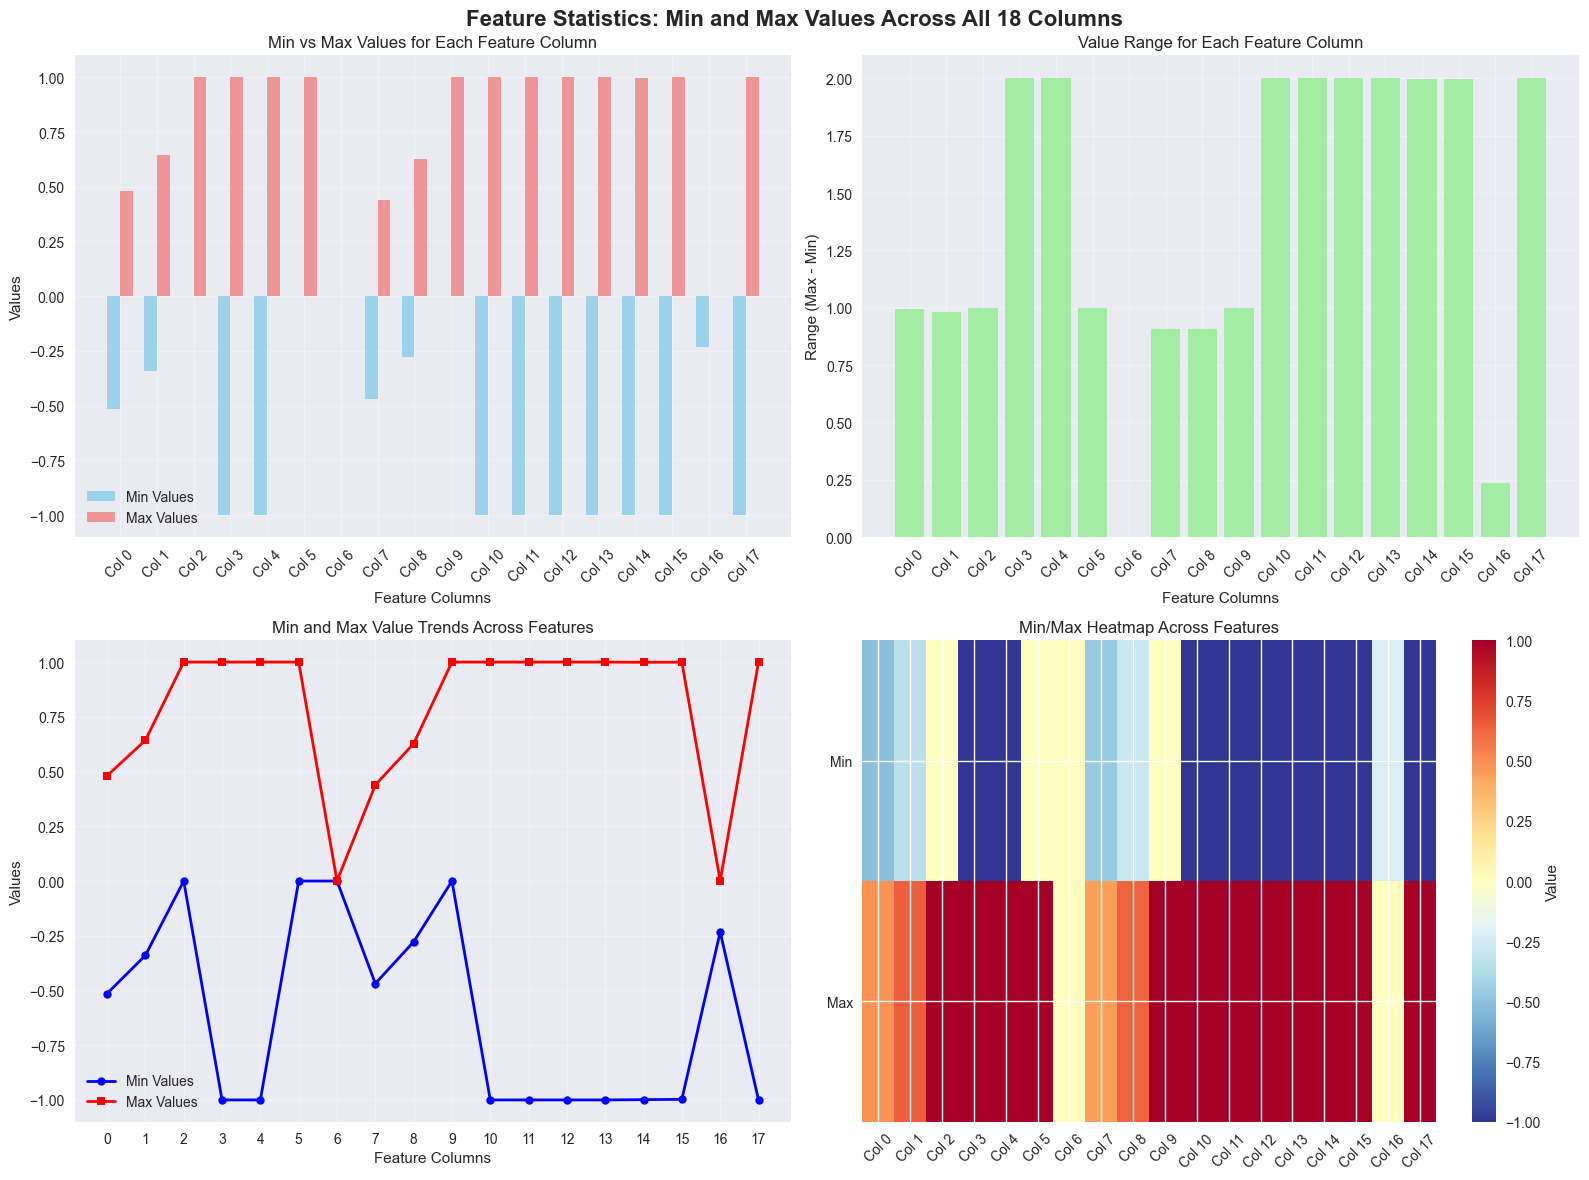


DETAILED FEATURE STATISTICS
Column  0 (Pos X       ): Min =  -0.514048, Max =   0.480895, Range =   0.994944
Column  1 (Pos Z       ): Min =  -0.339637, Max =   0.642920, Range =   0.982557
Column  2 (Rotation Y  ): Min =  -0.000016, Max =   0.999984, Range =   0.999999
Column  3 (Health      ): Min =  -1.000000, Max =   1.000000, Range =   2.000000
Column  4 (IsAlive     ): Min =  -1.000000, Max =   1.000000, Range =   2.000000
Column  5 (Energy      ): Min =   0.000000, Max =   1.000000, Range =   1.000000
Column  6 (Zero_6      ): Min =   0.000000, Max =   0.000000, Range =   0.000000
Column  7 (Enemy1 X    ): Min =  -0.468289, Max =   0.438709, Range =   0.906998
Column  8 (Enemy1 Z    ): Min =  -0.277844, Max =   0.627340, Range =   0.905185
Column  9 (Enemy1 Rot Y): Min =  -0.000015, Max =   0.999984, Range =   0.999999
Column 10 (Enemy1 Health): Min =  -1.000000, Max =   1.000000, Range =   2.000000
Column 11 (Enemy1 IsAlive): Min =  -1.000000, Max =   1.000000, Range =   2.000

In [52]:
# Create visualizations for min and max values
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Feature Statistics: Min and Max Values Across All 18 Columns', fontsize=16, fontweight='bold')

# Define feature names based on the preprocessing code
feature_names = [
    'Pos X', 'Pos Z', 'Rotation Y', 'Health', 'IsAlive', 
    'Energy', 'Zero_6', 'Enemy1 X', 'Enemy1 Z', 'Enemy1 Rot Y',
    'Enemy1 Health', 'Enemy1 IsAlive', 'Enemy2 X', 'Enemy2 Z', 'Enemy2 Rot Y',
    'Enemy2 Health', 'Distance', 'Dot Product'
]

column_indices = list(range(n_columns))

# Plot 1: Bar chart comparing min and max values
ax1 = axes[0, 0]
x_pos = np.arange(len(column_indices))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, global_mins, width, label='Min Values', alpha=0.8, color='skyblue')
bars2 = ax1.bar(x_pos + width/2, global_maxs, width, label='Max Values', alpha=0.8, color='lightcoral')

ax1.set_xlabel('Feature Columns')
ax1.set_ylabel('Values')
ax1.set_title('Min vs Max Values for Each Feature Column')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'Col {i}' for i in column_indices], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Range (max - min) for each column
ax2 = axes[0, 1]
ranges = [global_maxs[i] - global_mins[i] for i in range(n_columns)]
bars = ax2.bar(column_indices, ranges, color='lightgreen', alpha=0.8)
ax2.set_xlabel('Feature Columns')
ax2.set_ylabel('Range (Max - Min)')
ax2.set_title('Value Range for Each Feature Column')
ax2.set_xticks(column_indices)
ax2.set_xticklabels([f'Col {i}' for i in column_indices], rotation=45)
ax2.grid(True, alpha=0.3)

# Plot 3: Line plot showing min and max trends
ax3 = axes[1, 0]
ax3.plot(column_indices, global_mins, 'o-', label='Min Values', linewidth=2, markersize=6, color='blue')
ax3.plot(column_indices, global_maxs, 's-', label='Max Values', linewidth=2, markersize=6, color='red')
ax3.set_xlabel('Feature Columns')
ax3.set_ylabel('Values')
ax3.set_title('Min and Max Value Trends Across Features')
ax3.set_xticks(column_indices)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Heatmap-style visualization
ax4 = axes[1, 1]
data_matrix = np.array([global_mins, global_maxs])
im = ax4.imshow(data_matrix, cmap='RdYlBu_r', aspect='auto')
ax4.set_yticks([0, 1])
ax4.set_yticklabels(['Min', 'Max'])
ax4.set_xticks(column_indices)
ax4.set_xticklabels([f'Col {i}' for i in column_indices], rotation=45)
ax4.set_title('Min/Max Heatmap Across Features')

# Add colorbar
cbar = plt.colorbar(im, ax=ax4)
cbar.set_label('Value')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*80)
print("DETAILED FEATURE STATISTICS")
print("="*80)
for i in range(n_columns):
    feature_name = feature_names[i] if i < len(feature_names) else f"Feature {i}"
    print(f"Column {i:2d} ({feature_name:12s}): Min = {global_mins[i]:10.6f}, Max = {global_maxs[i]:10.6f}, Range = {global_maxs[i] - global_mins[i]:10.6f}")


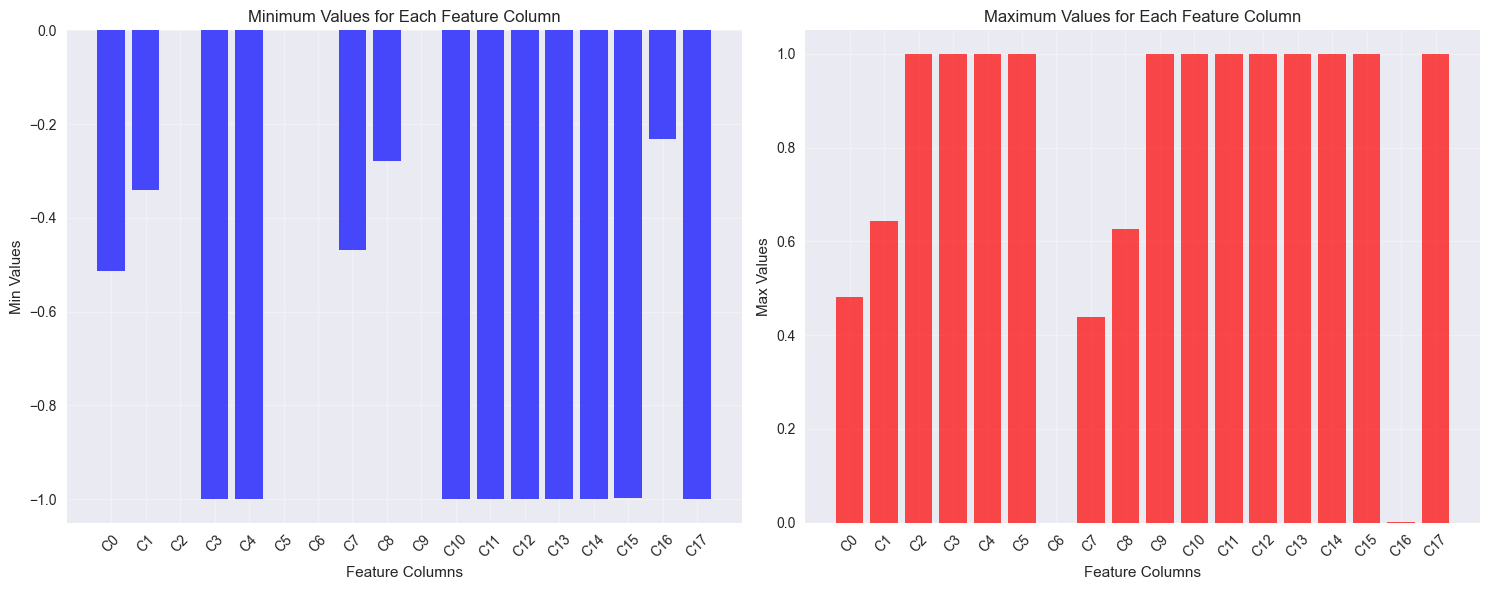


SUMMARY STATISTICS
Total feature files processed: 3479950
Feature matrix shape per file: (20, 18)
Total data points analyzed: 69599000 trajectories

Overall statistics:
Absolute minimum value across all features: -1.000000
Absolute maximum value across all features: 1.000000
Largest range (max-min): 2.000000
Smallest range (max-min): 0.000000

Columns with constant values (zero range): [6]


In [53]:
# Additional focused visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Separate scales for better visibility of small values
ax1 = axes[0]
x_pos = np.arange(n_columns)
ax1.bar(x_pos, global_mins, alpha=0.7, color='blue', label='Min Values')
ax1.set_xlabel('Feature Columns')
ax1.set_ylabel('Min Values')
ax1.set_title('Minimum Values for Each Feature Column')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'C{i}' for i in range(n_columns)], rotation=45)
ax1.grid(True, alpha=0.3)

# Plot 2: Max values on separate scale
ax2 = axes[1]
ax2.bar(x_pos, global_maxs, alpha=0.7, color='red', label='Max Values')
ax2.set_xlabel('Feature Columns')
ax2.set_ylabel('Max Values')
ax2.set_title('Maximum Values for Each Feature Column')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'C{i}' for i in range(n_columns)], rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total feature files processed: {len(feature_files)}")
print(f"Feature matrix shape per file: (20, 18)")
print(f"Total data points analyzed: {len(feature_files) * 20} trajectories")
print("\nOverall statistics:")
print(f"Absolute minimum value across all features: {min(global_mins):.6f}")
print(f"Absolute maximum value across all features: {max(global_maxs):.6f}")
print(f"Largest range (max-min): {max([global_maxs[i] - global_mins[i] for i in range(n_columns)]):.6f}")
print(f"Smallest range (max-min): {min([global_maxs[i] - global_mins[i] for i in range(n_columns)]):.6f}")

# Identify columns with zero range (constant values)
zero_range_cols = [i for i in range(n_columns) if abs(global_maxs[i] - global_mins[i]) < 1e-10]
if zero_range_cols:
    print(f"\nColumns with constant values (zero range): {zero_range_cols}")
else:
    print("\nNo columns have constant values across the dataset.")


In [ ]:
output_dir = '/Users/vaibhavmishra/Desktop/Desktop/btx-game-aicode/clash_squad_agent_trajectories_processed'

import os
import numpy as np

# List all files in the output directory
files = os.listdir(output_dir)
print("Files in output directory:", len(files))



Files in output directory: 6891514


In [47]:
print(files[1023])

trajectory_28679_actions_3002545.npy


In [46]:

new_output_dir = "/Users/vaibhavmishra/Desktop/Desktop/btx-game-aicode/clash_squad_agent_trajectories_processed"
action_output_dir = os.path.join(new_output_dir, "actions")
feature_output_dir = os.path.join(new_output_dir, "features")
os.makedirs(new_output_dir, exist_ok=True)
os.makedirs(action_output_dir, exist_ok=True)
os.makedirs(feature_output_dir, exist_ok=True)
for file in files:
    if "actions" in file and ".npy" in file:
        
        actions = np.load(os.path.join(output_dir, file))

        if(actions[0]>0.5):
            actions[0] = 0.5
        elif(actions[0] < -0.5):
            actions[0] = -0.5
        if(actions[1]>0.5):
            actions[1] = 0.5
        elif(actions[1] < -0.5):
            actions[1] = -0.5
        np.save(os.path.join(action_output_dir, file), actions)
        
    elif "features" in file and ".npy" in file:
    
        features = np.load(os.path.join(output_dir, file))
        print(features.shape)
        # Edit first column of features array
        features[:, 0] = features[:, 0] / 1000.0 
        features[:, 1] = features[:, 1] / 1000.0 
        features[:, 2] = features[:, 2] / 360
        features[:, 5] = features[:, 5] / 100
        features[:, 6] = 0
        features[:, 7] = features[:, 7] / 1000.0 
        features[:, 8] = features[:, 8] / 1000.0 
        features[:, 9] = features[:, 9] / 360
        features[:, 16] = features[:, 16] / 1000.0 
        


        print("Modified features shape:", features.shape)
        print("First column values:", features[:, 0])
        np.save(os.path.join(feature_output_dir, file), features)
        
    


(20, 18)


In [29]:
action_x = []
action_y = []
for file in files:
    if "action" in file:
        actions = np.load(os.path.join(output_dir, file))
        action_x.append(float(actions[0])) 
        action_y.append(float(actions[1])) 



In [30]:
for i in range(len(action_x)):
    if(action_x[i]>0.5):
        action_x[i]=0.5
    elif(action_x[i] < -0.5):
        action_x[i] = -0.5
    if(action_y[i]>0.5):
        action_y[i]=0.5
    elif(action_y[i] < -0.5):
        action_y[i] = -0.5


In [31]:
import matplotlib.pyplot as plt
import numpy as np

print(f"Total action files processed: {len(action_x)}")
print(f"Action X range: {min(action_x):.3f} to {max(action_x):.3f}")
print(f"Action Y range: {min(action_y):.3f} to {max(action_y):.3f}")
print(f"Action X mean: {np.mean(action_x):.3f}, std: {np.std(action_x):.3f}")
print(f"Action Y mean: {np.mean(action_y):.3f}, std: {np.std(action_y):.3f}")


Total action files processed: 3479950
Action X range: -0.500 to 0.500
Action Y range: -0.500 to 0.500
Action X mean: -0.018, std: 0.225
Action Y mean: 0.004, std: 0.217


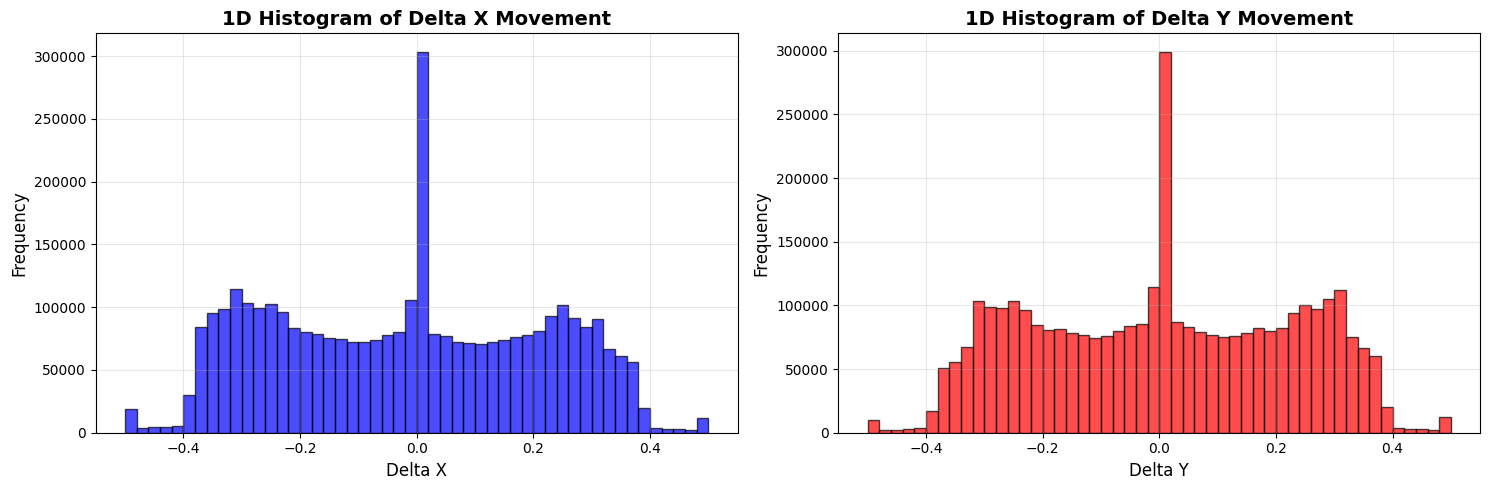

In [32]:
# Create 1D histograms for action_x and action_y
plt.figure(figsize=(15, 5))

# Action X histogram
plt.subplot(1, 2, 1)
plt.hist(action_x, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.title('1D Histogram of Delta X Movement', fontsize=14, fontweight='bold')
plt.xlabel('Delta X', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

# Action Y histogram  
plt.subplot(1, 2, 2)
plt.hist(action_y, bins=50, alpha=0.7, color='red', edgecolor='black')
plt.title('1D Histogram of Delta Y Movement', fontsize=14, fontweight='bold')
plt.xlabel('Delta Y', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


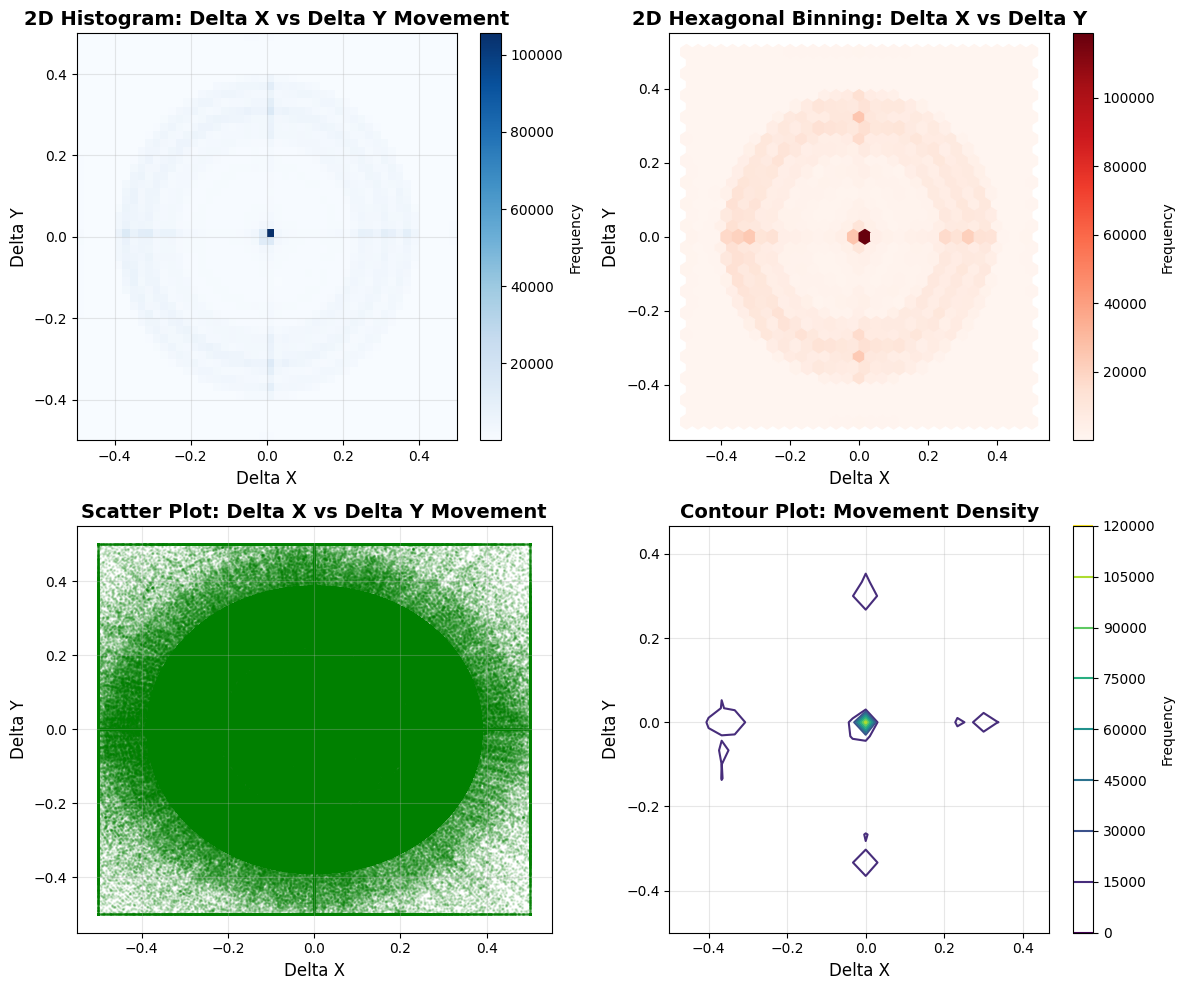

In [33]:
# Create 2D histogram showing delta_x and delta_y movement together
plt.figure(figsize=(12, 10))

# 2D histogram with hexbin
plt.subplot(2, 2, 1)
plt.hist2d(action_x, action_y, bins=50, cmap='Blues')
plt.colorbar(label='Frequency')
plt.title('2D Histogram: Delta X vs Delta Y Movement', fontsize=14, fontweight='bold')
plt.xlabel('Delta X', fontsize=12)
plt.ylabel('Delta Y', fontsize=12)
plt.grid(True, alpha=0.3)

# Hexagonal binning for better visualization
plt.subplot(2, 2, 2)
plt.hexbin(action_x, action_y, gridsize=30, cmap='Reds', mincnt=1)
plt.colorbar(label='Frequency')
plt.title('2D Hexagonal Binning: Delta X vs Delta Y', fontsize=14, fontweight='bold')
plt.xlabel('Delta X', fontsize=12)
plt.ylabel('Delta Y', fontsize=12)

# Scatter plot with density
plt.subplot(2, 2, 3)
plt.scatter(action_x, action_y, alpha=0.1, s=1, c='green')
plt.title('Scatter Plot: Delta X vs Delta Y Movement', fontsize=14, fontweight='bold')
plt.xlabel('Delta X', fontsize=12)
plt.ylabel('Delta Y', fontsize=12)
plt.grid(True, alpha=0.3)

# Contour plot
plt.subplot(2, 2, 4)
# Create a 2D histogram for contour
hist, xedges, yedges = np.histogram2d(action_x, action_y, bins=30)
X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
plt.contour(X, Y, hist.T, levels=10, cmap='viridis')
plt.colorbar(label='Frequency')
plt.title('Contour Plot: Movement Density', fontsize=14, fontweight='bold')
plt.xlabel('Delta X', fontsize=12)
plt.ylabel('Delta Y', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


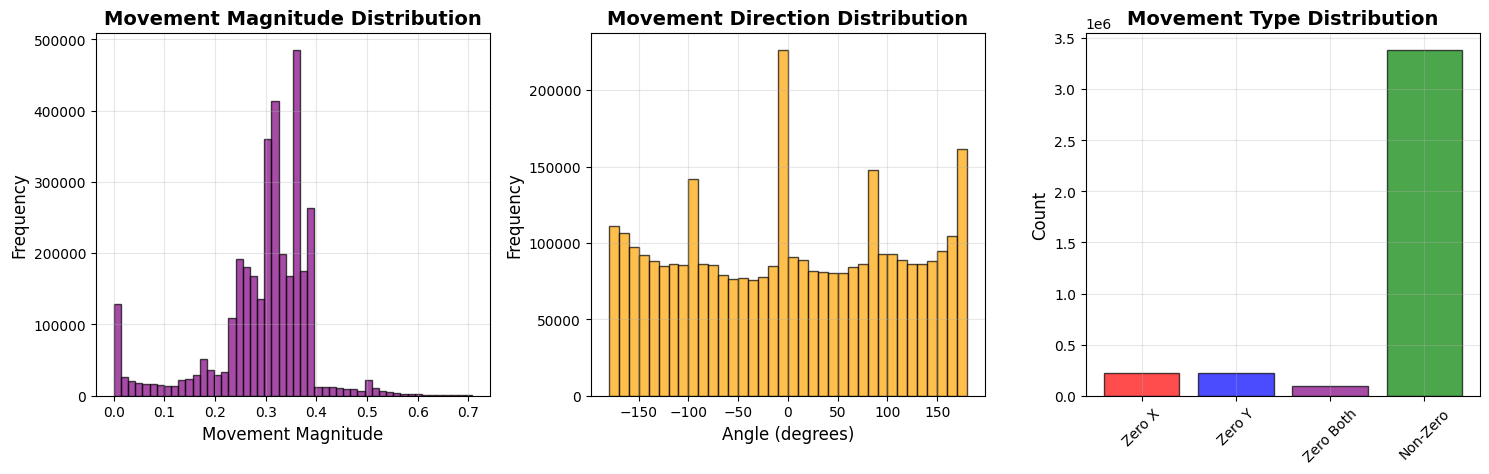

\nMovement Statistics:
Average movement magnitude: 0.296
Max movement magnitude: 0.707
Percentage of zero movements: 2.73%


In [34]:
# Additional analysis: Movement patterns
plt.figure(figsize=(15, 5))

# Distribution analysis
plt.subplot(1, 3, 1)
combined_movement = np.sqrt(np.array(action_x)**2 + np.array(action_y)**2)
plt.hist(combined_movement, bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.title('Movement Magnitude Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Movement Magnitude', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

# Movement direction analysis
plt.subplot(1, 3, 2)
movement_angles = np.arctan2(action_y, action_x) * 180 / np.pi
plt.hist(movement_angles, bins=36, alpha=0.7, color='orange', edgecolor='black')
plt.title('Movement Direction Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Angle (degrees)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

# Zero movement analysis
plt.subplot(1, 3, 3)
zero_x = sum(1 for x in action_x if abs(x) < 0.001)
zero_y = sum(1 for y in action_y if abs(y) < 0.001)
zero_both = sum(1 for x, y in zip(action_x, action_y) if abs(x) < 0.001 and abs(y) < 0.001)

categories = ['Zero X', 'Zero Y', 'Zero Both', 'Non-Zero']
values = [zero_x, zero_y, zero_both, len(action_x) - zero_both]
colors = ['red', 'blue', 'purple', 'green']

plt.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Movement Type Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\\nMovement Statistics:")
print(f"Average movement magnitude: {np.mean(combined_movement):.3f}")
print(f"Max movement magnitude: {np.max(combined_movement):.3f}")
print(f"Percentage of zero movements: {(zero_both/len(action_x)*100):.2f}%")


In [50]:
feature_output_dir = '/Users/vaibhavmishra/Desktop/Desktop/btx-game-aicode/clash_squad_agent_trajectories_processed/features'

import os
import numpy as np

# List all files in the output directory
files = os.listdir(feature_output_dir)
print("Files in output directory:", len(files))

Files in output directory: 3479950
